# CHUQ corpus: proton ay

The CHUQ corpus is a reconstruction of the experimental data used in the CH89 global optical potential analysis, assembled from EXFOR by the supplement's authors and tabulated in Supplemental Material B.

Proton analyzing powers, dimensionless, against CM scattering angle.

The subentries and scattering energies below are transcribed from the supplement's
tables into `spec/chuq_proton_ay.csv`. Every row must be accounted for: it either
produces data, or it is listed in `spec/known_missing.csv` with a reason. Uncertainties
are assigned by the supplement's preference rule (`nn_corpora.errors`), and the
corrections its Comments describe are applied from `nn_corpora.overrides`.

In [1]:
%matplotlib inline
import matplotlib
from matplotlib import pyplot as plt

import pandas as pd

from nn_corpora import corpus, plotting, report, spec

pd.set_option("display.max_rows", 200)

Using database version X4-2025-12-31 located in: /mnt/home/beyerkyl/x4db/unpack_exfor-2025/X4-2025-12-31


## The specification

In [2]:
rows = spec.load_sector('chuq', 'proton_ay')
print(f"{len(rows)} rows, {len({r.subentry for r in rows if r.in_exfor})} distinct subentries")
pd.DataFrame([vars(r) for r in rows]).head(15)

82 rows, 82 distinct subentries


,corpus,sector,projectile,target_A,target_Z,target_label,energy_mev,energy_hi_mev,subentry,pointer,pdf_page
0,chuq,proton_ay,proton,40,20,40Ca,65.0,None,O0032002,A,24
1,chuq,proton_ay,proton,44,20,44Ca,65.0,None,O0032056,A,24
2,chuq,proton_ay,proton,46,22,46Ti,65.0,None,O0032058,A,24
3,chuq,proton_ay,proton,48,20,48Ca,65.0,None,O0032057,A,24
4,chuq,proton_ay,proton,48,22,48Ti,16.0,None,C0893005,,24
5,chuq,proton_ay,proton,48,22,48Ti,65.0,None,O0032059,A,24
6,chuq,proton_ay,proton,50,22,50Ti,16.0,None,C0893007,,24
7,chuq,proton_ay,proton,50,22,50Ti,65.0,None,O0032060,A,24
8,chuq,proton_ay,proton,54,26,54Fe,16.0,None,C0893009,,24
9,chuq,proton_ay,proton,54,26,54Fe,17.2,None,O0091003,,24


## Retrieve and clean

`corpus.curate` retrieves each entry, matches measurements back to the rows that asked
for them, applies the documented corrections, and homogenises units and frames.

In [3]:
result = corpus.curate('chuq', 'proton_ay')
print(result.summary())

chuq/proton_ay
  spec rows              82
  ... marked absent      0
  ... resolved           79 / 82 (96.3%)
  measurements           64
  data points            1950
  EXFOR entries          8
  unresolved by category
    x4i3-parse-failure       3
  serialized             64 measurements, 1950 points
  dropped during cleaning
    O0091003: one or more data points carry no uncertainty
    O0091009: one or more data points carry no uncertainty
    O0091015: one or more data points carry no uncertainty
    O0091019: one or more data points carry no uncertainty
    O0091023: one or more data points carry no uncertainty
    O0169007: one or more data points carry no uncertainty
    O0169013: one or more data points carry no uncertainty
    O0169015: one or more data points carry no uncertainty
    O1103005: one or more data points carry no uncertainty
    O1103007: one or more data points carry no uncertainty
    O1103013: one or more data points carry no uncertainty
    O1103015: one o

## Rows that did not resolve

Every row listed here must appear in `spec/known_missing.csv`, or the write below will
fail. The categories are: `absent-from-exfor` (the supplement itself marks the row as
not locatable), `x4i3-parse-failure` (the entry is in EXFOR but x4i3 cannot read it),
`subentry-withdrawn` (EXFOR has renumbered or removed the subentry since the supplement
was written), `energy-not-found`, and `uncertainty-unresolved`.

In [4]:
print(report.unresolved_table(result.data))

54Fe    40.000 O0162024  [x4i3-parse-failure] uncertainty unresolved (entry-unavailable): entry O0162 is not in the x4i3 index; it is most likely one of the entries x4i3 fails to parse
58Ni    40.000 O0162026  [x4i3-parse-failure] uncertainty unresolved (entry-unavailable): entry O0162 is not in the x4i3 index; it is most likely one of the entries x4i3 fails to parse
60Ni    40.000 O0162028  [x4i3-parse-failure] uncertainty unresolved (entry-unavailable): entry O0162 is not in the x4i3 index; it is most likely one of the entries x4i3 fails to parse


## Uncertainty audit

Data sets with missing uncertainties are dropped during munging, following the
supplement's removal of any data set lacking a necessary feature. This lists anything
that survived but still looks suspicious.

In [5]:
flags = plotting.check_uncertainties(result)
print("\n".join(flags) if flags else "every measurement carries uncertainties")

every measurement carries uncertainties


## Inspect

Every parsed data set is plotted, one figure per target, grouped by incident energy and
offset for legibility. Outliers here are found by eye: a mistranscribed point shows up
as a single datum an order of magnitude away from its neighbours; a badly normalised
data set shows up as a whole curve offset from others at the same energy. Nothing is
sampled or truncated -- the count of plotted data sets is checked against the number
written below, because a data set that is never drawn is one whose outliers are never
found.

/mnt/ufs18/rs/reactiontheoryinitiative/nucleon_nucleus_data/src/nn_corpora/plotting.py:54: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, axes = plt.subplots(1, n_plots, figsize=(6 * n_plots, y_size), squeeze=False)


plotted all 64 data sets


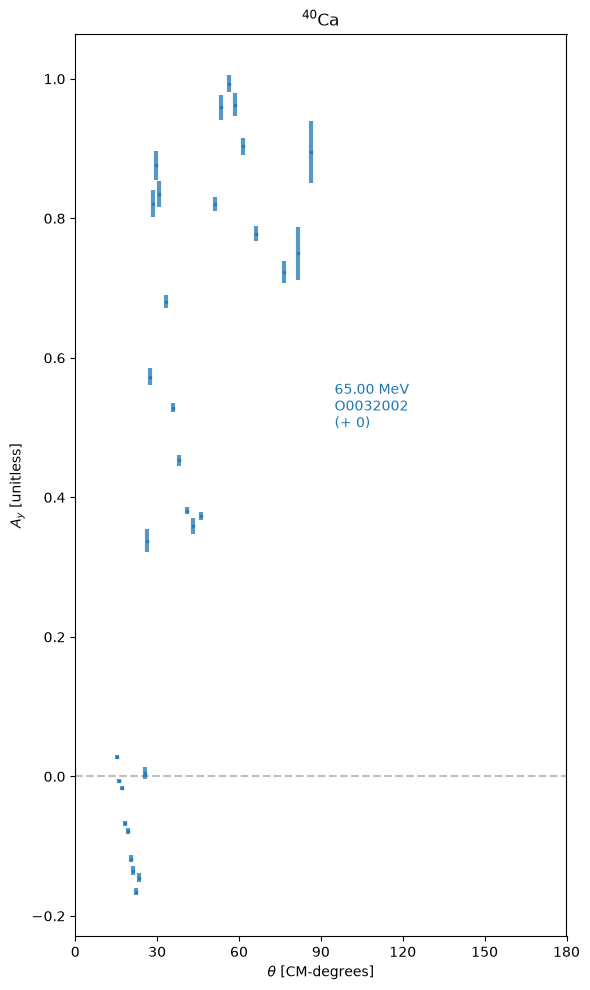

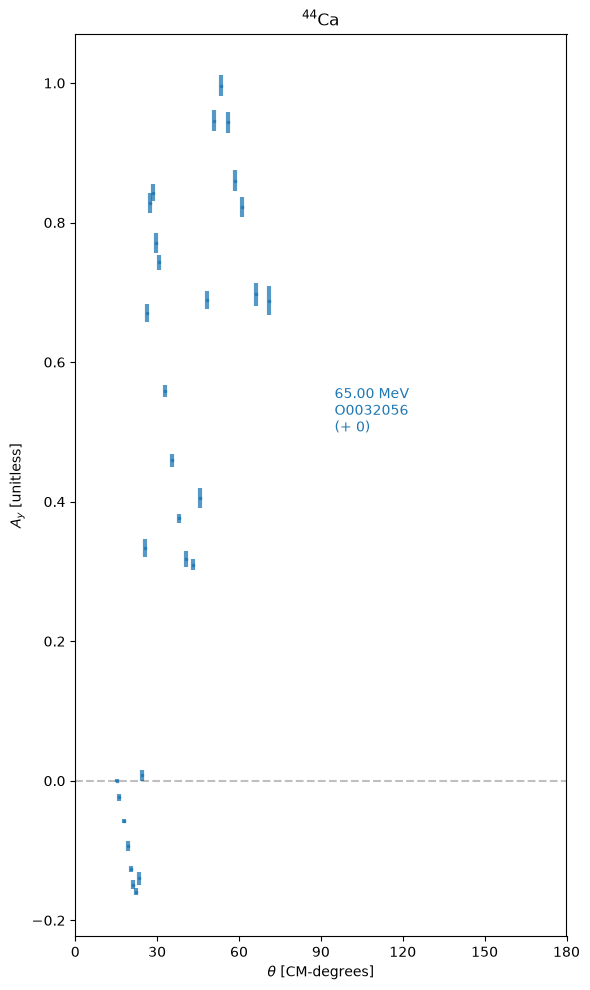

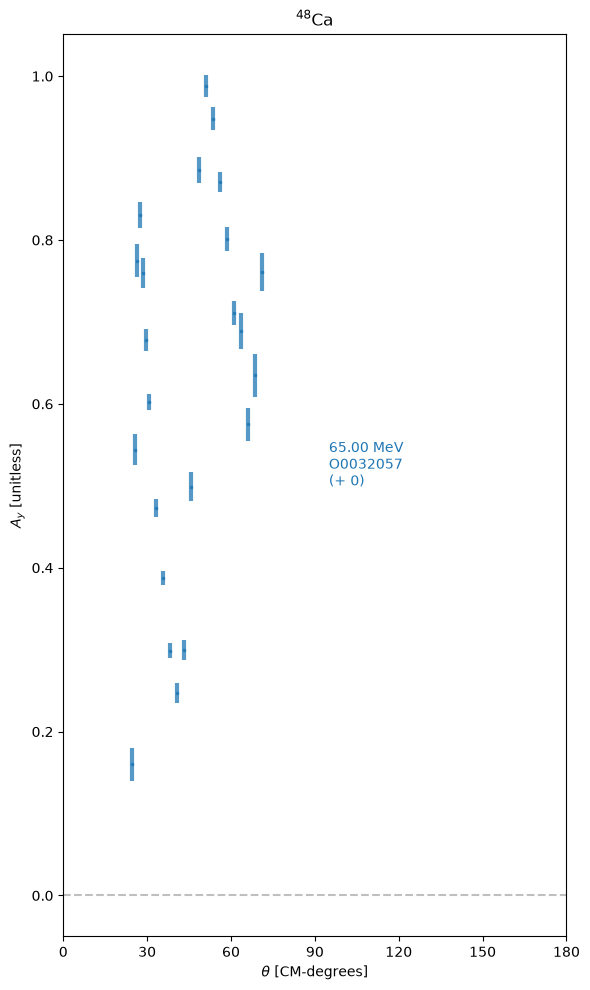

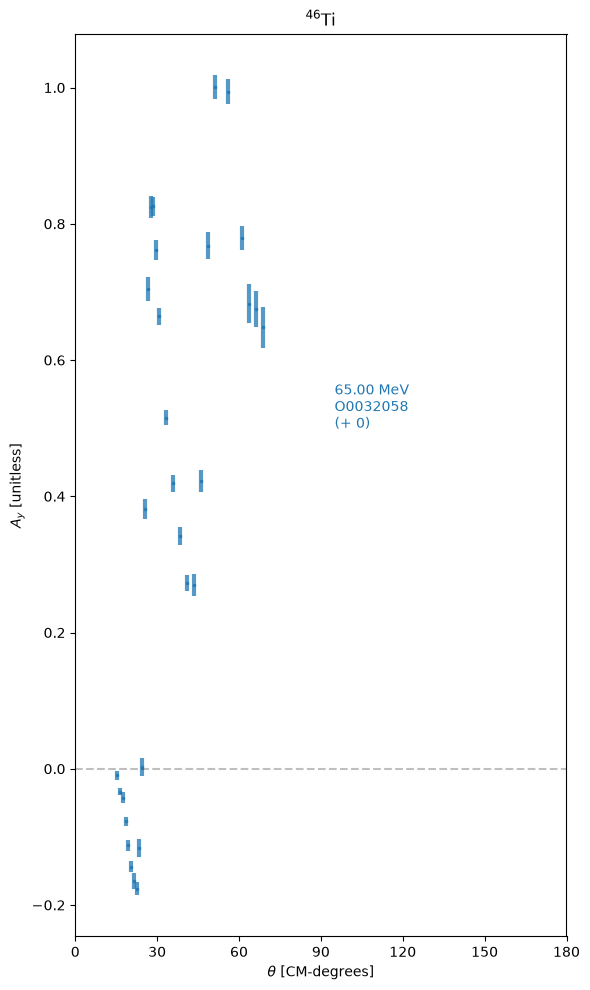

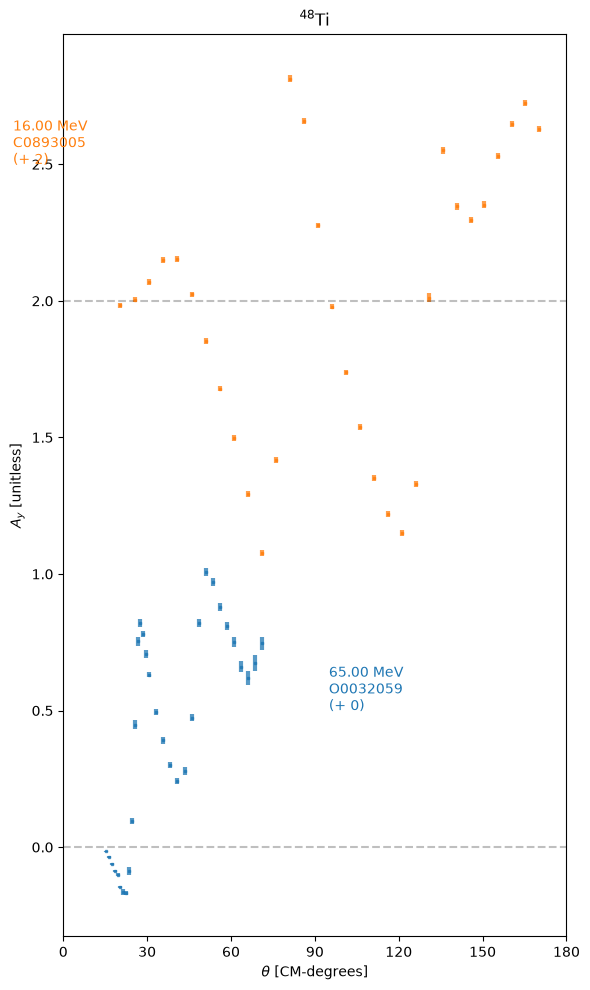

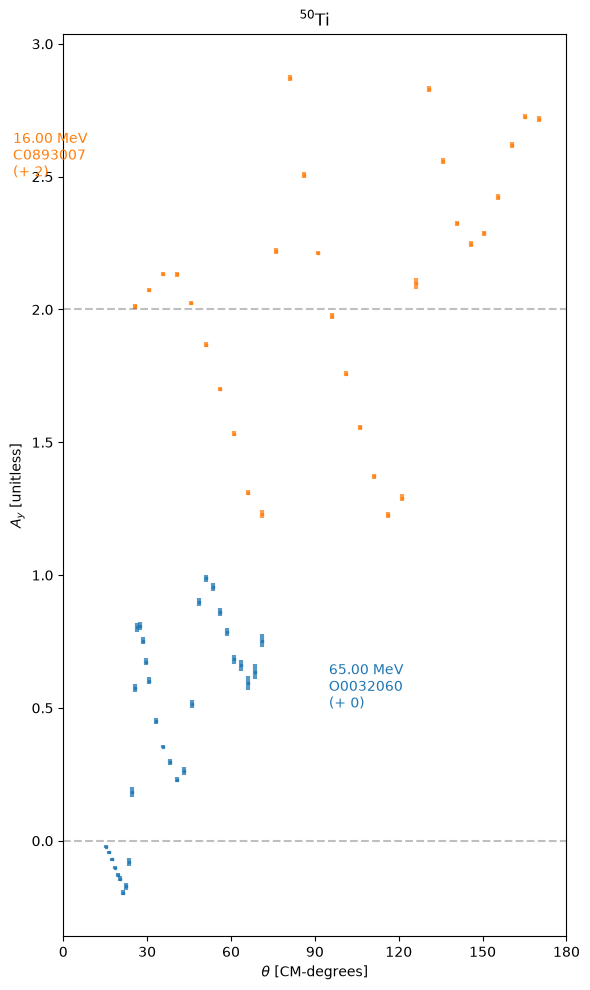

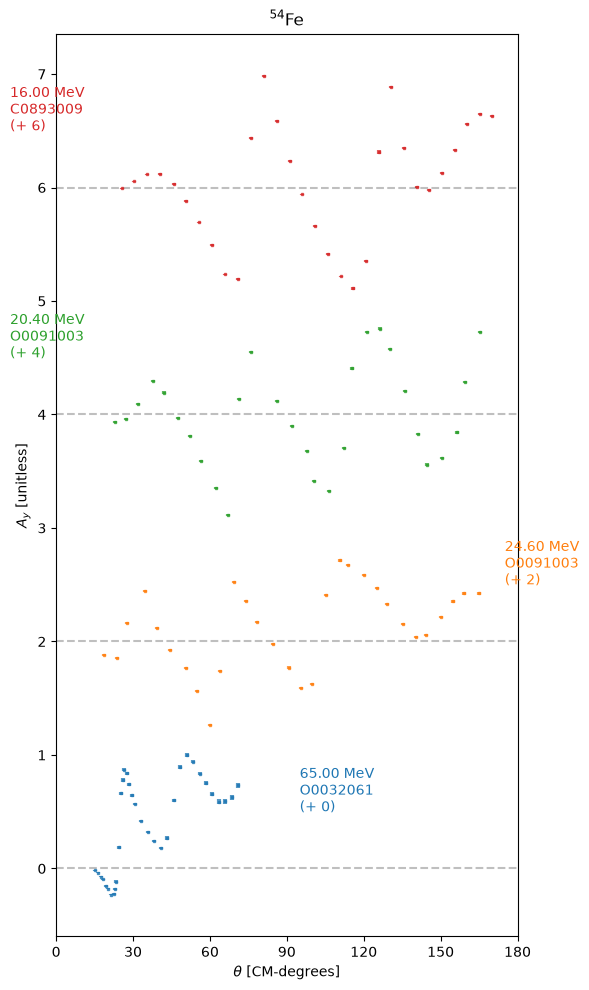

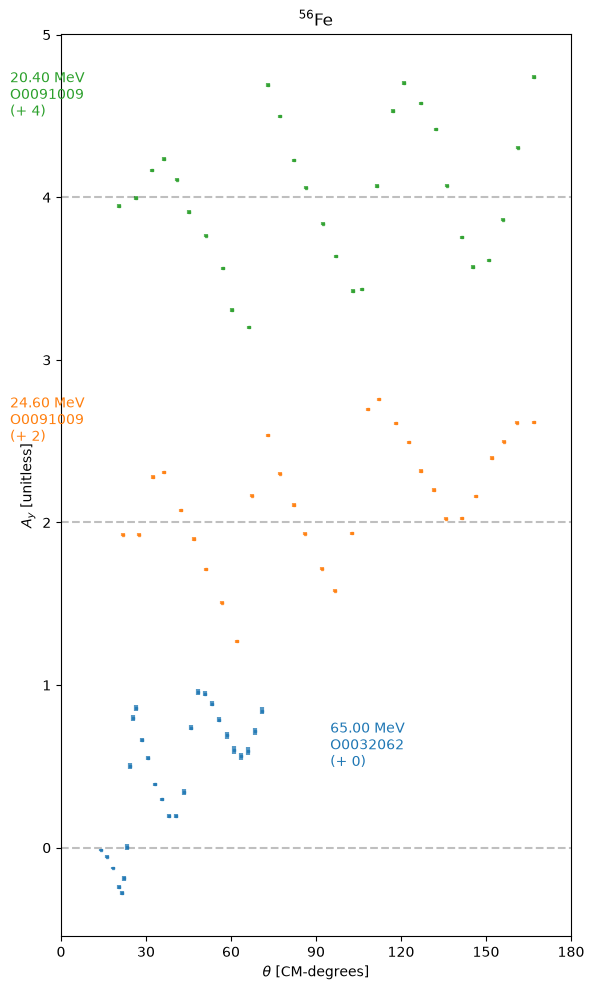

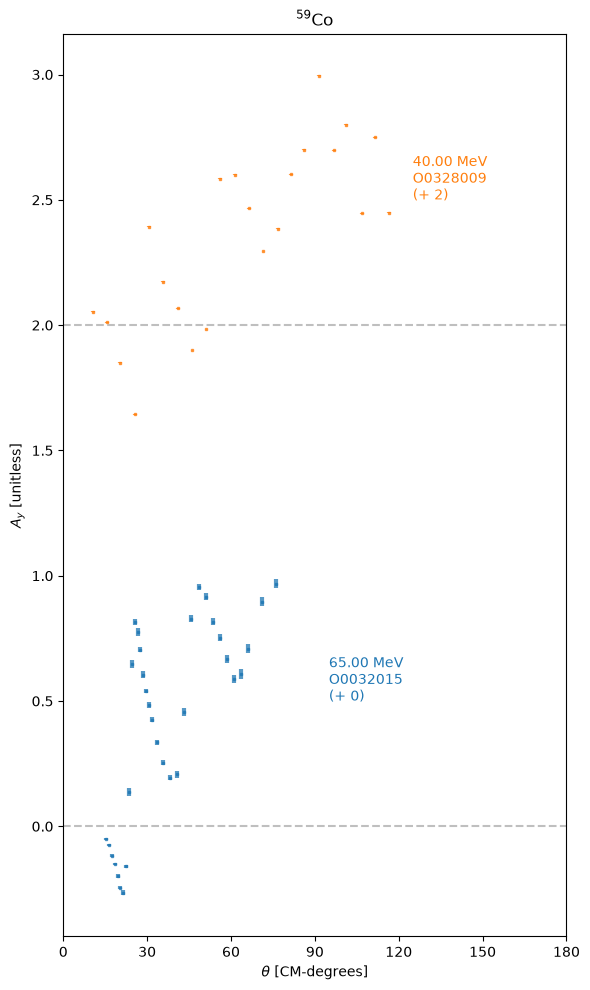

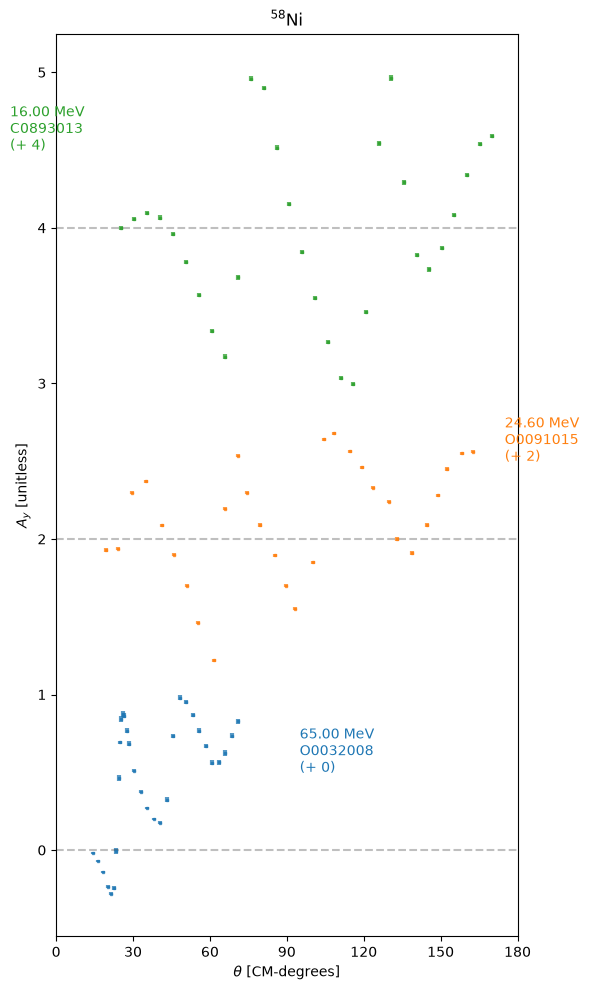

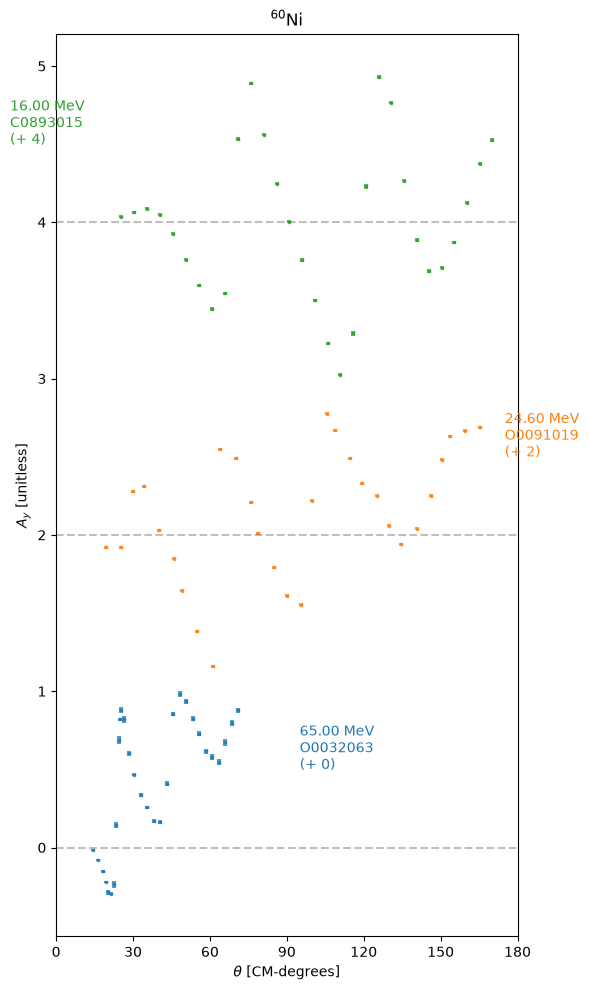

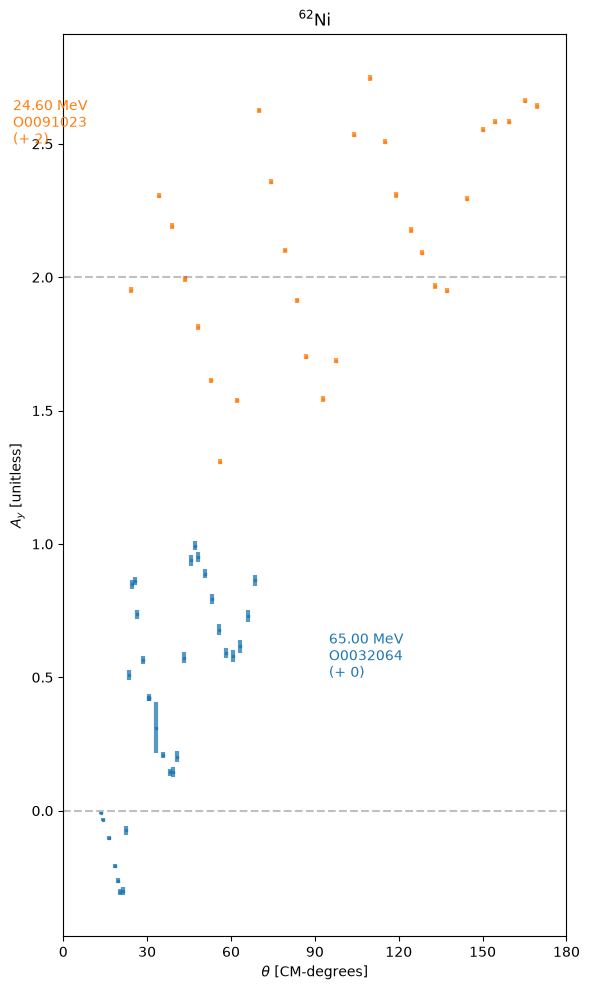

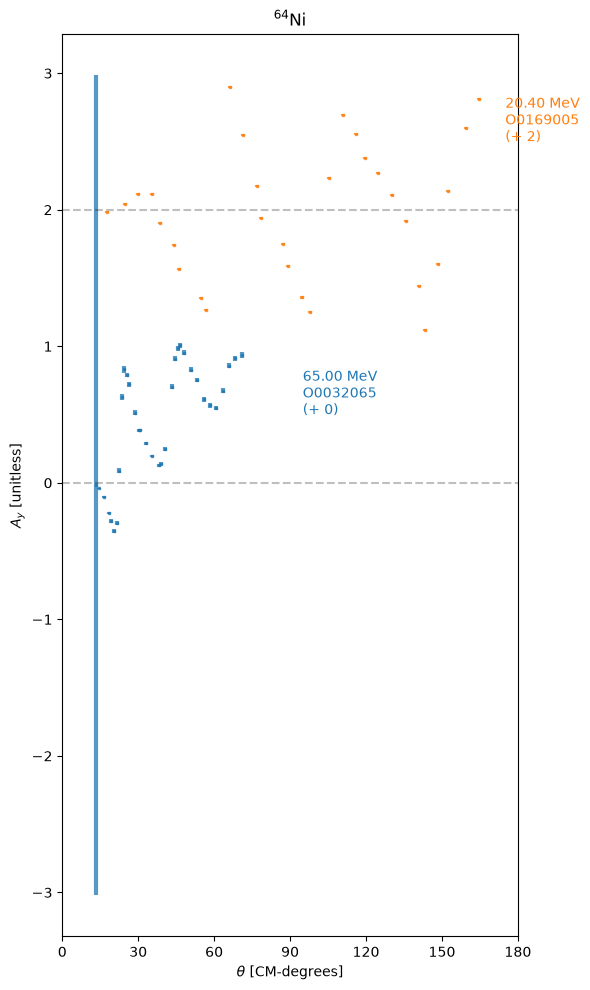

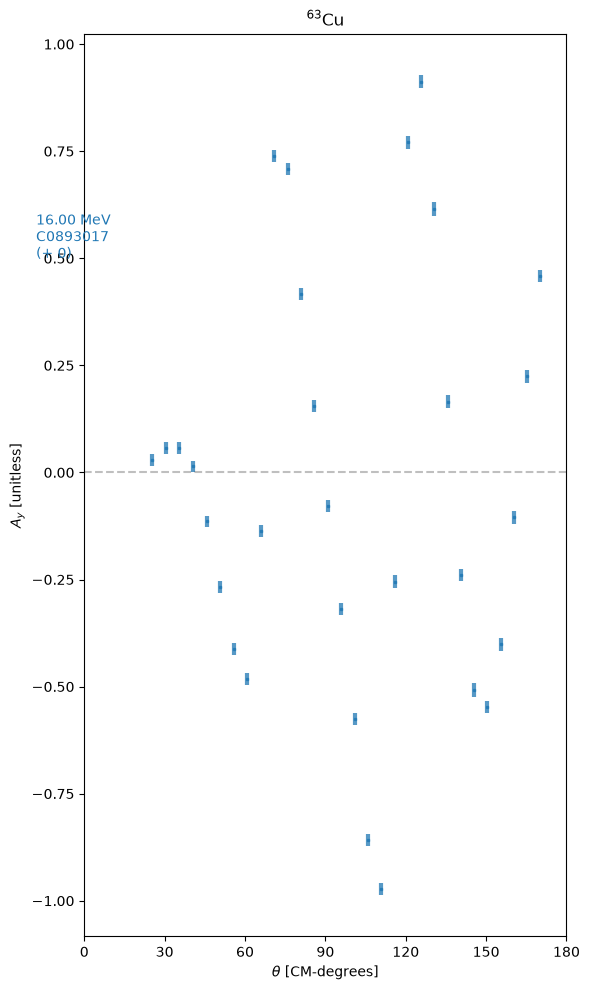

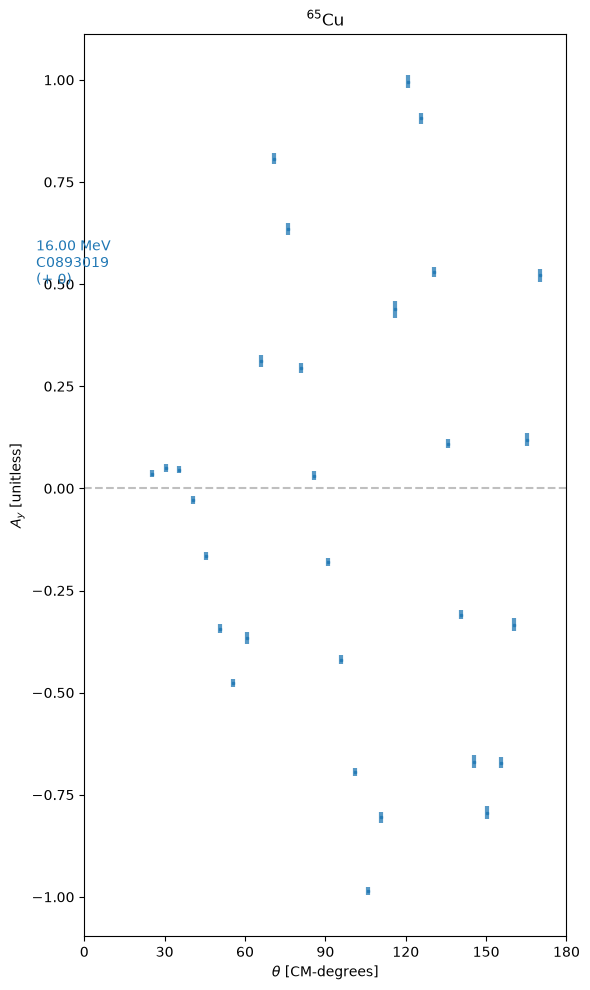

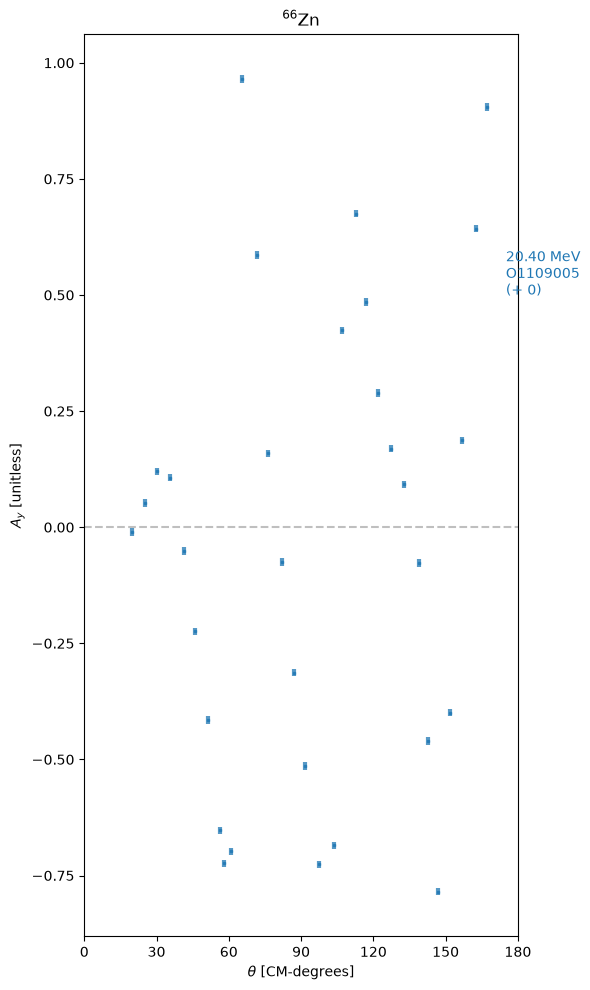

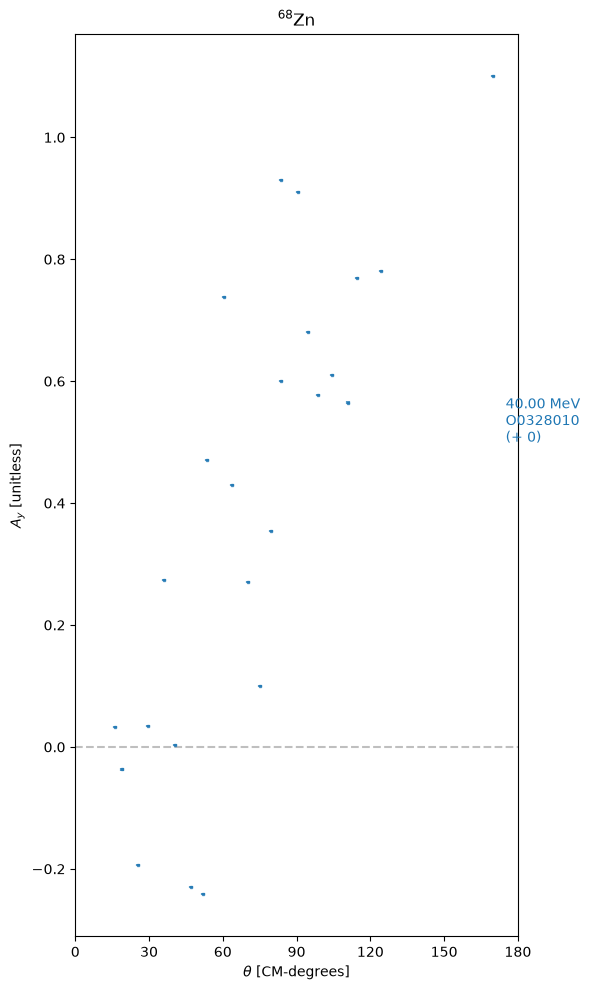

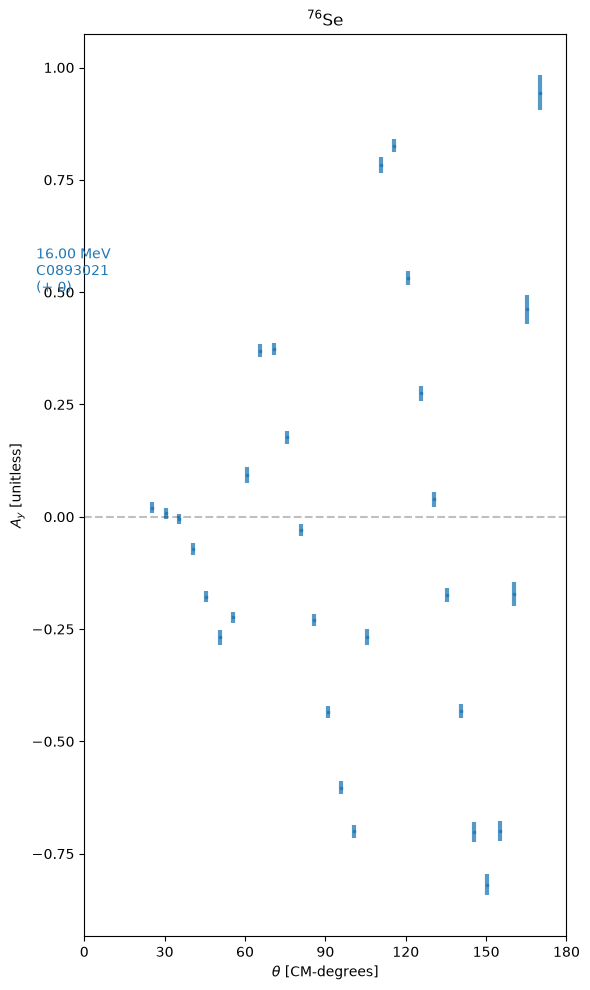

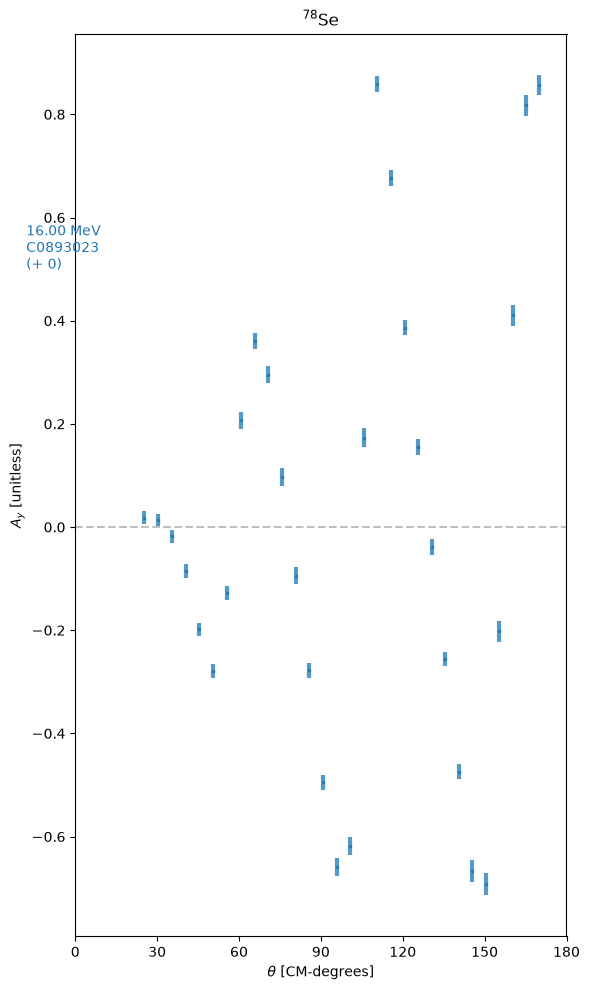

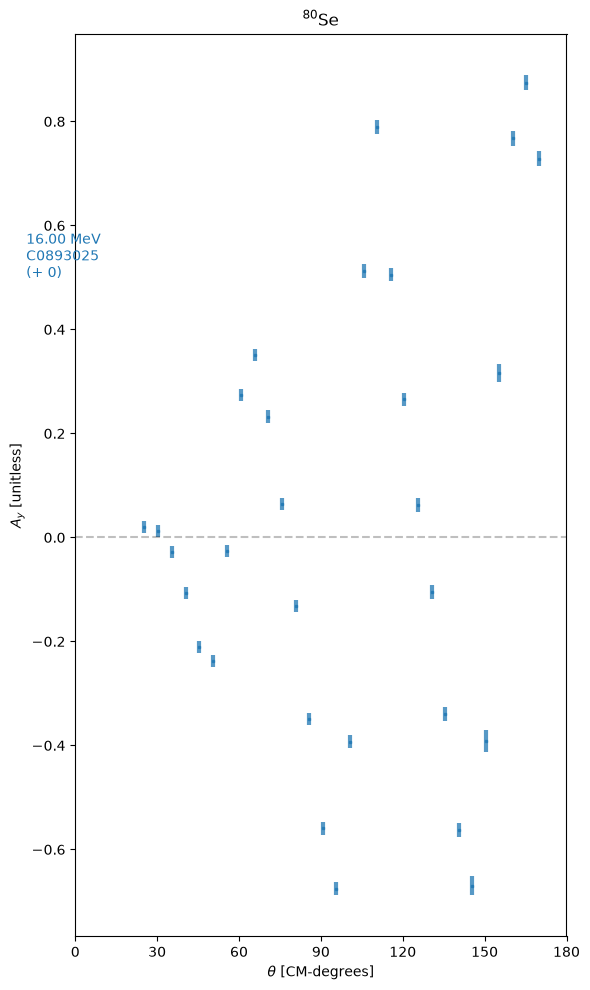

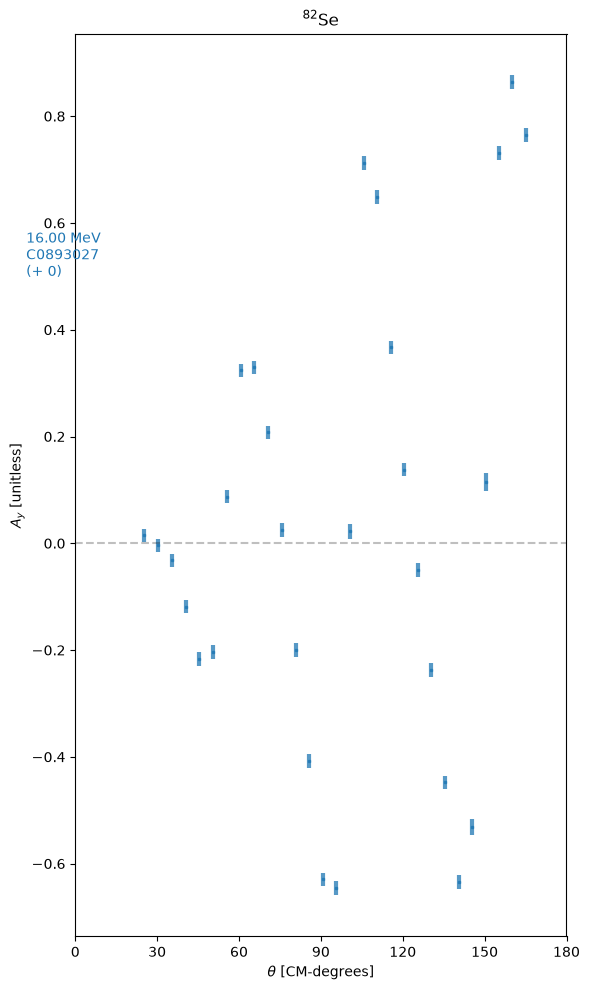

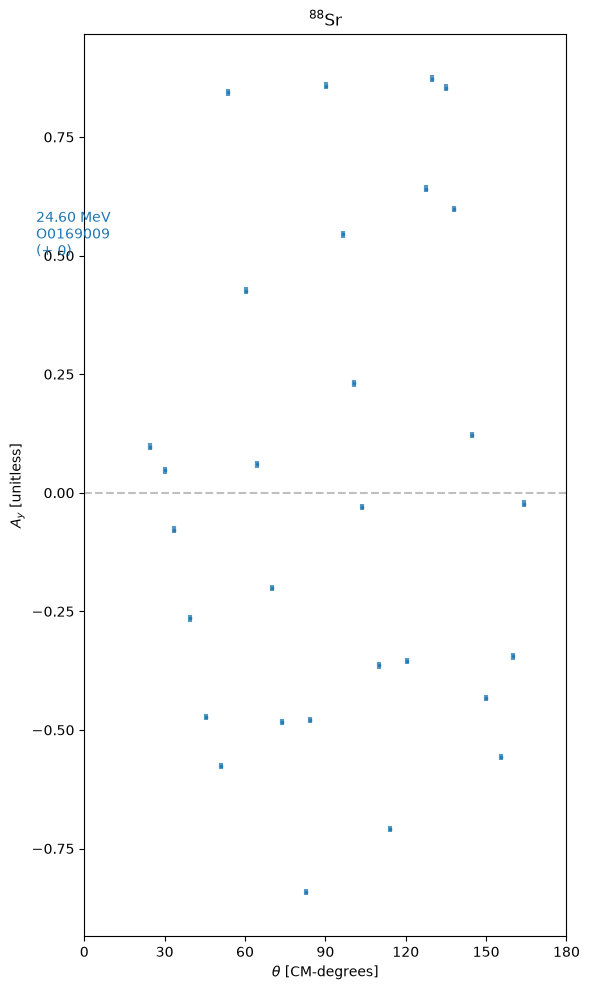

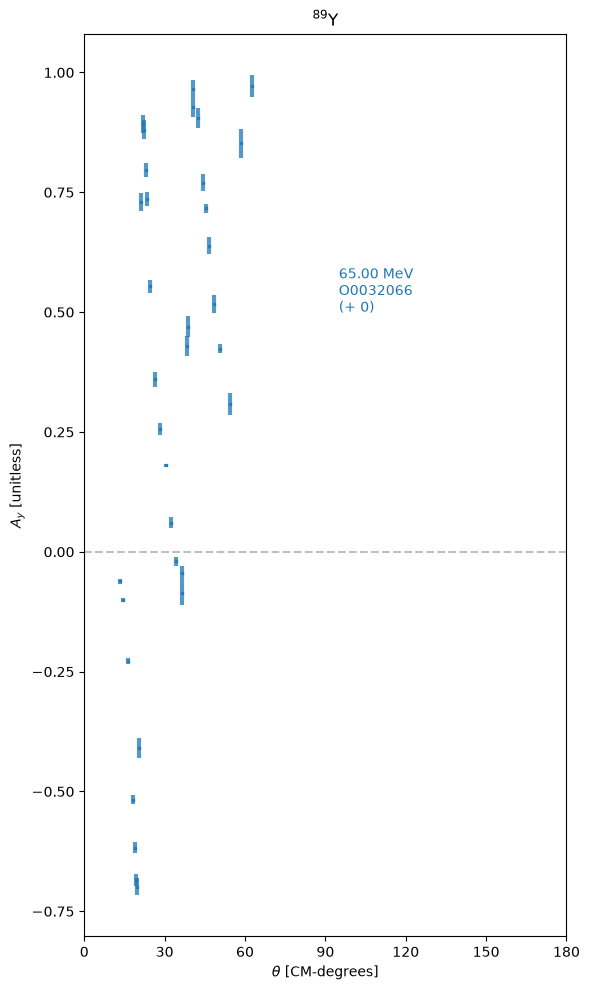

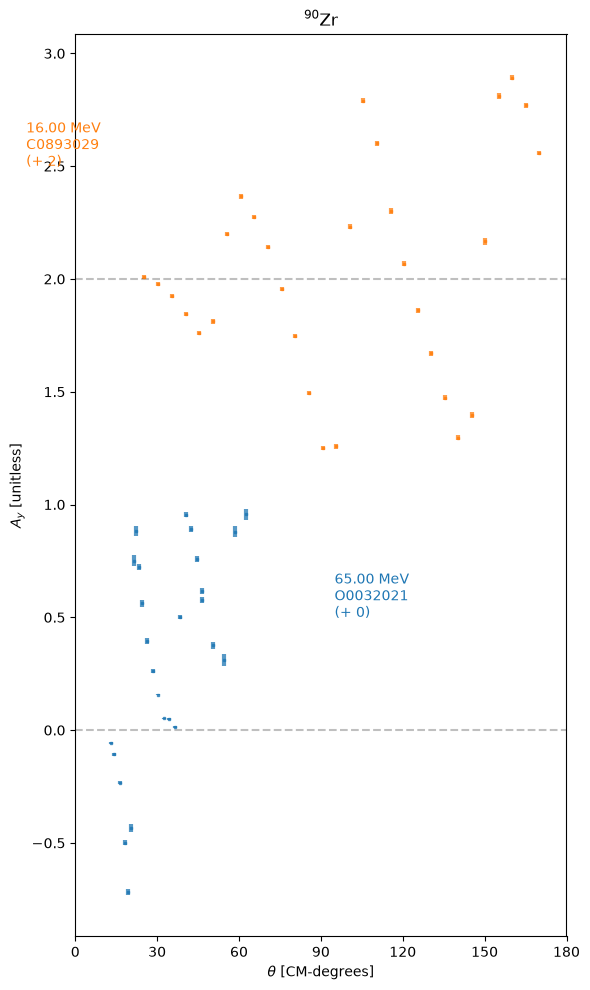

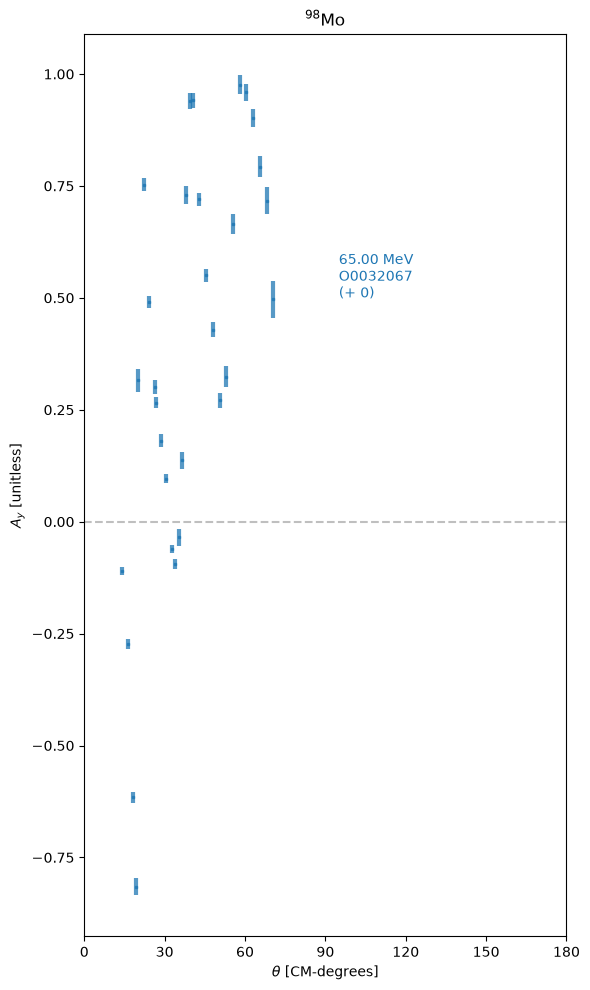

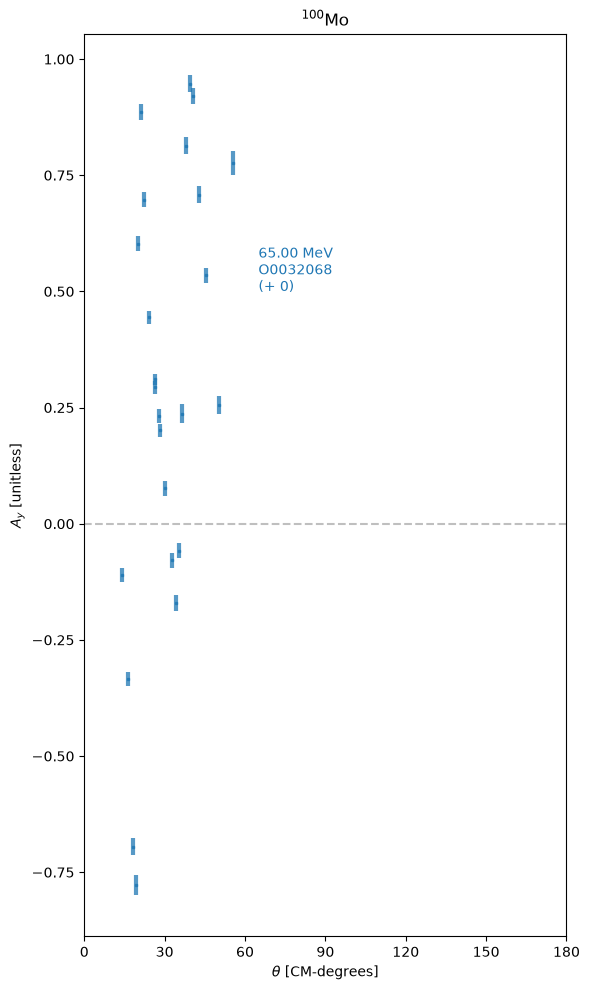

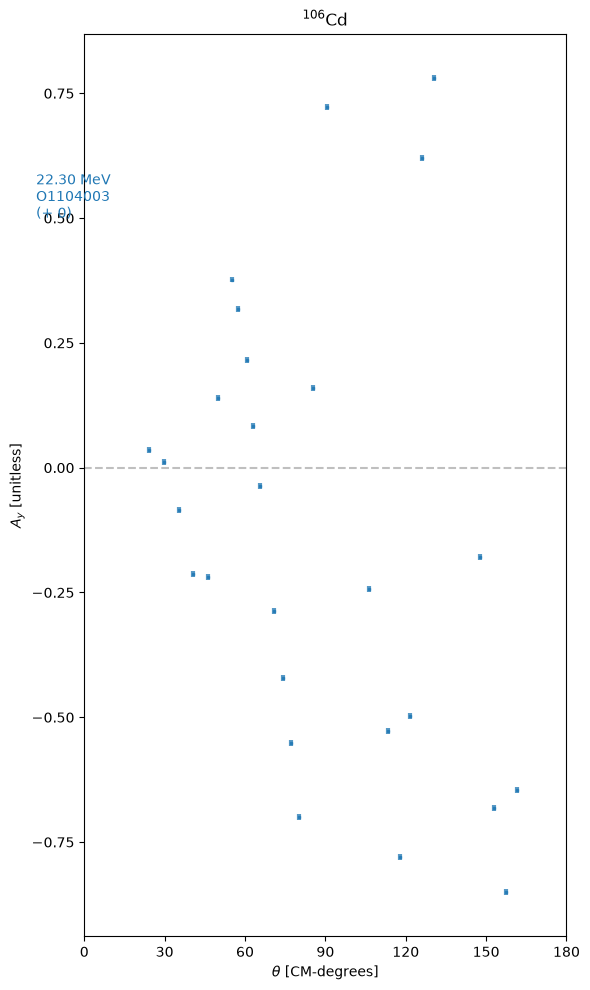

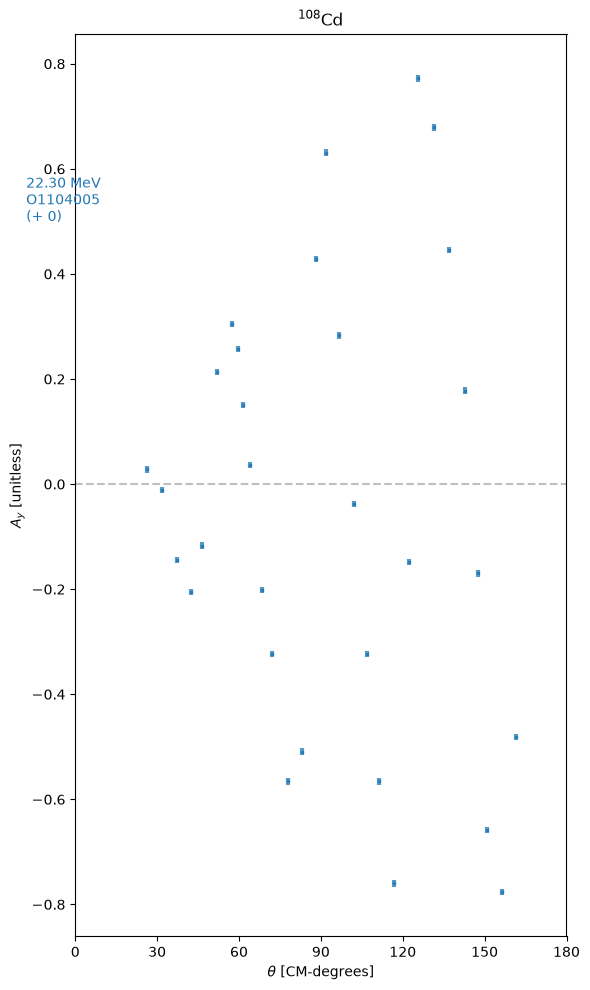

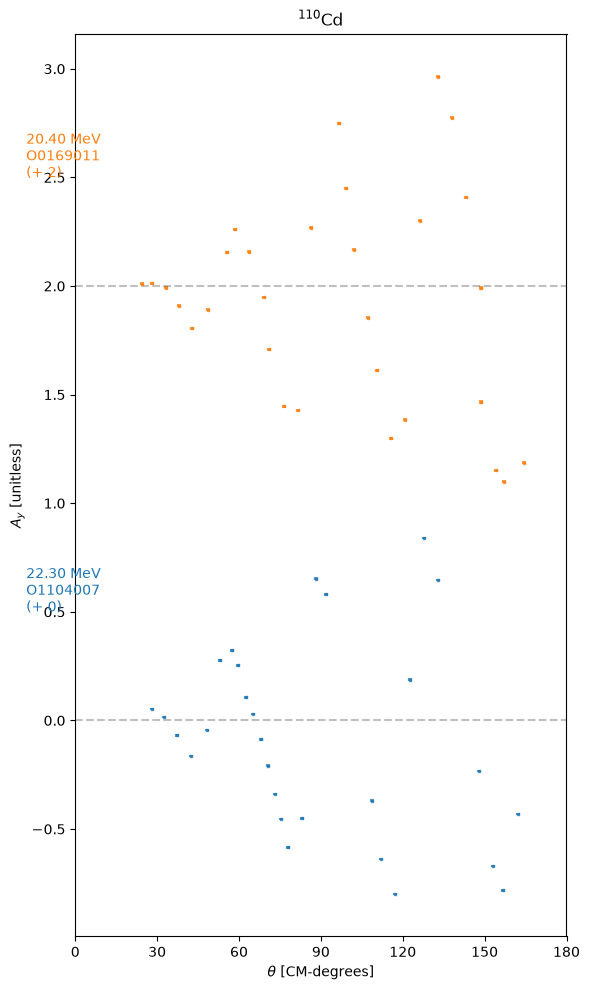

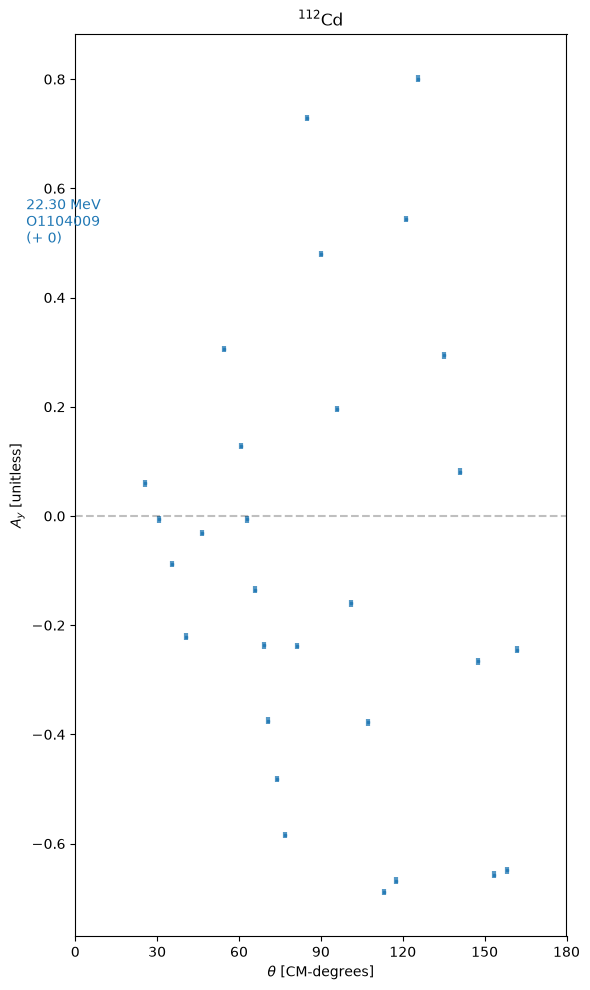

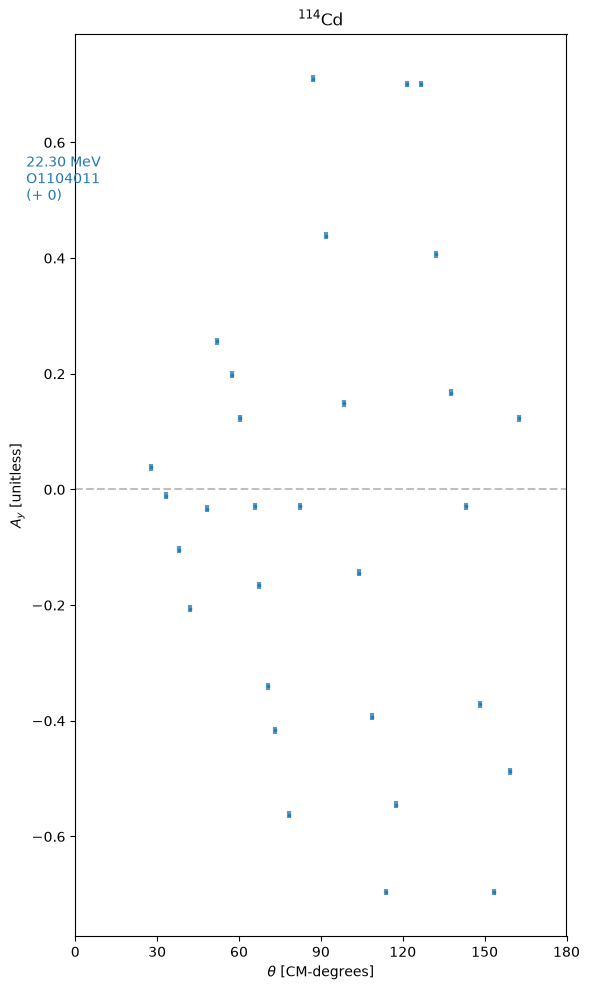

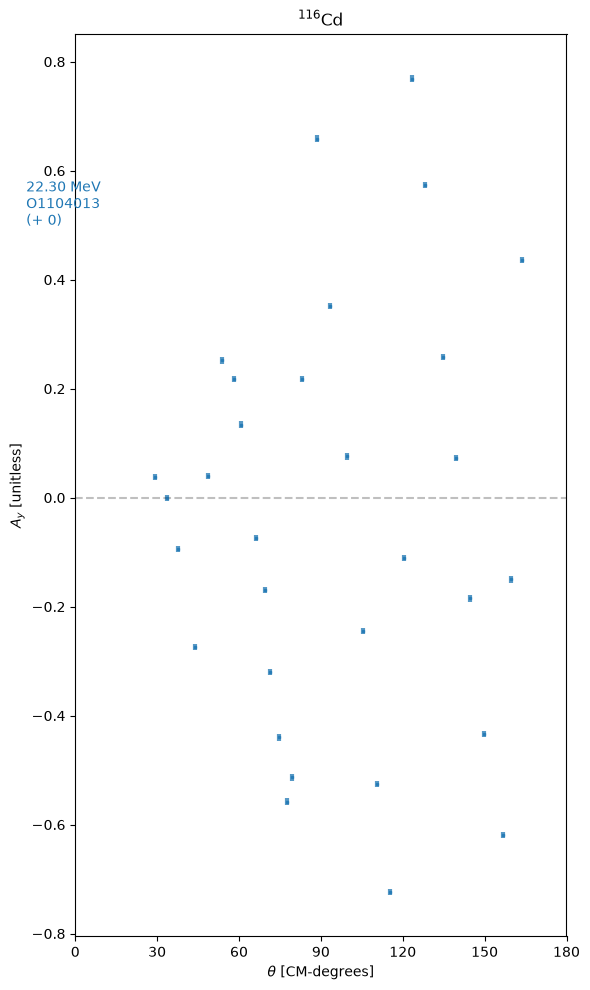

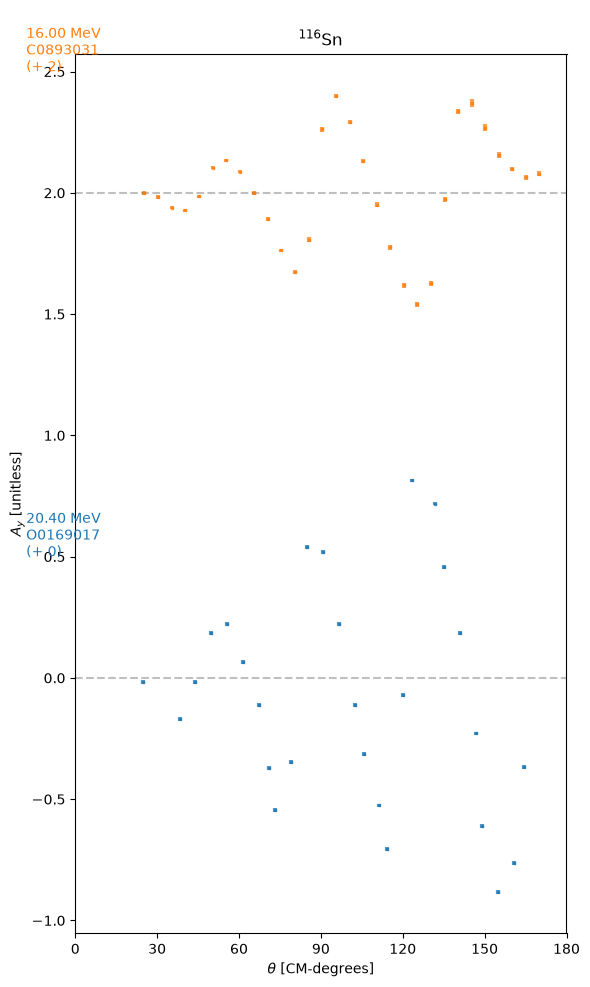

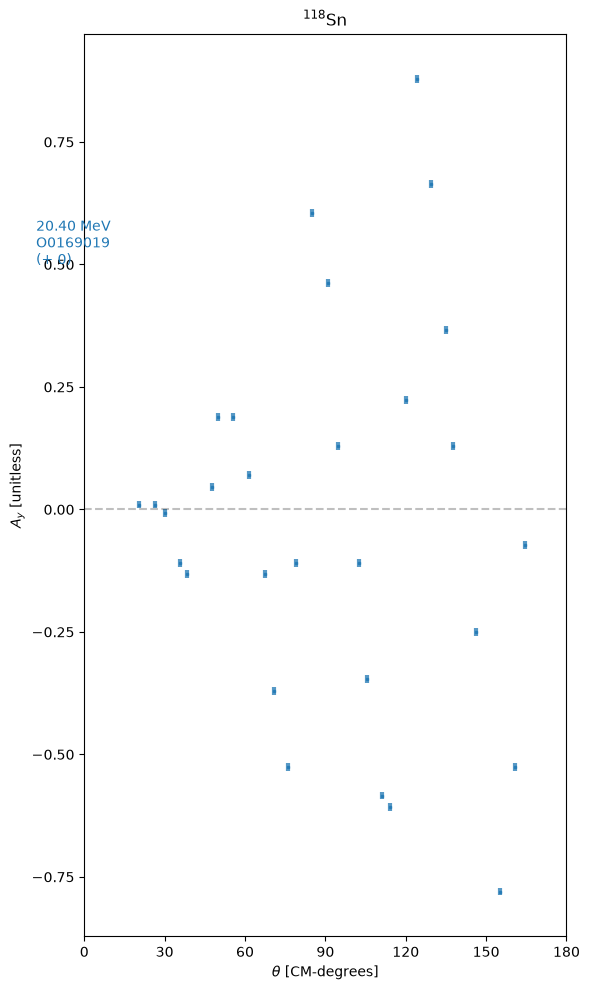

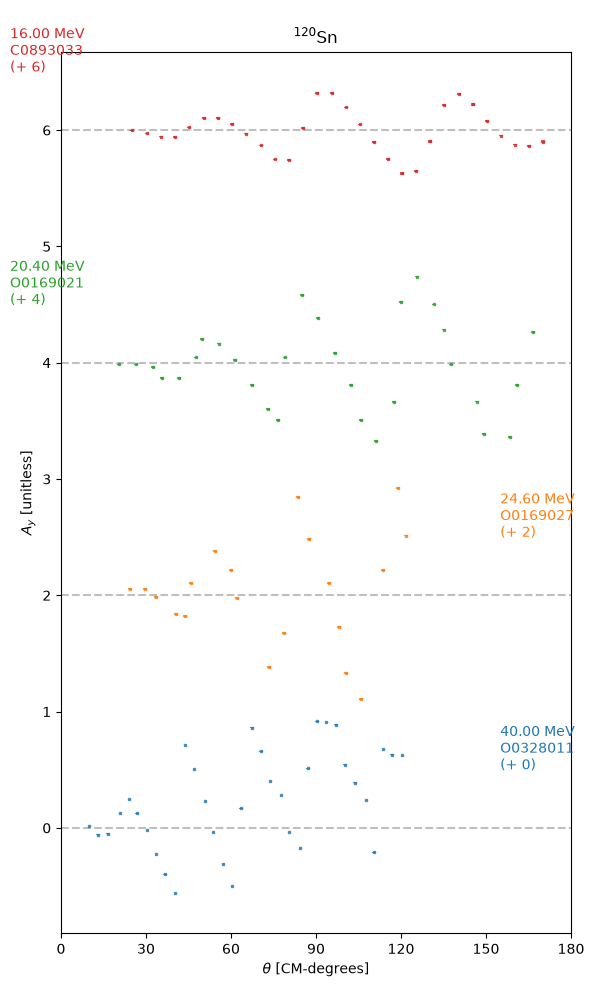

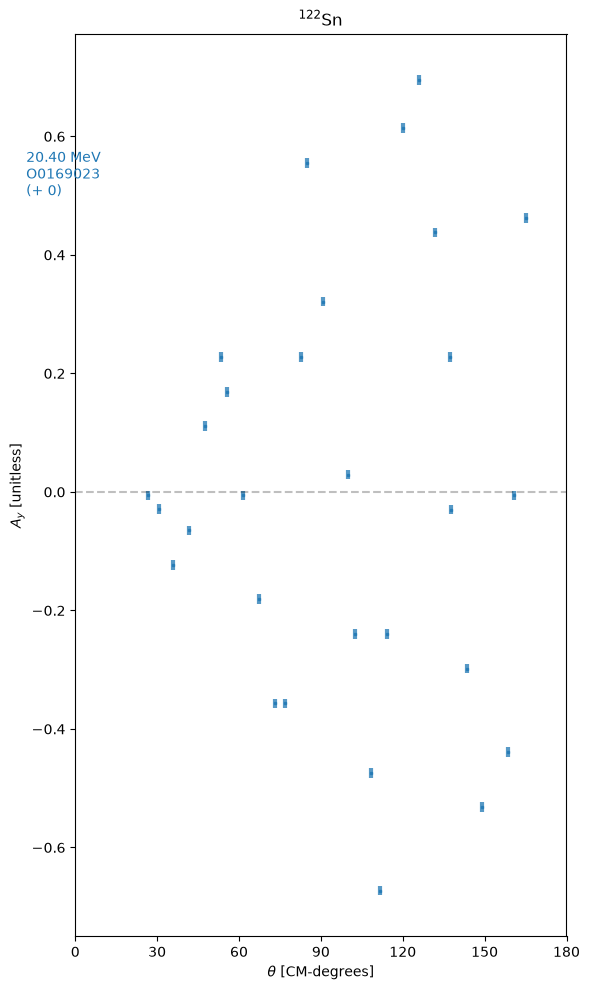

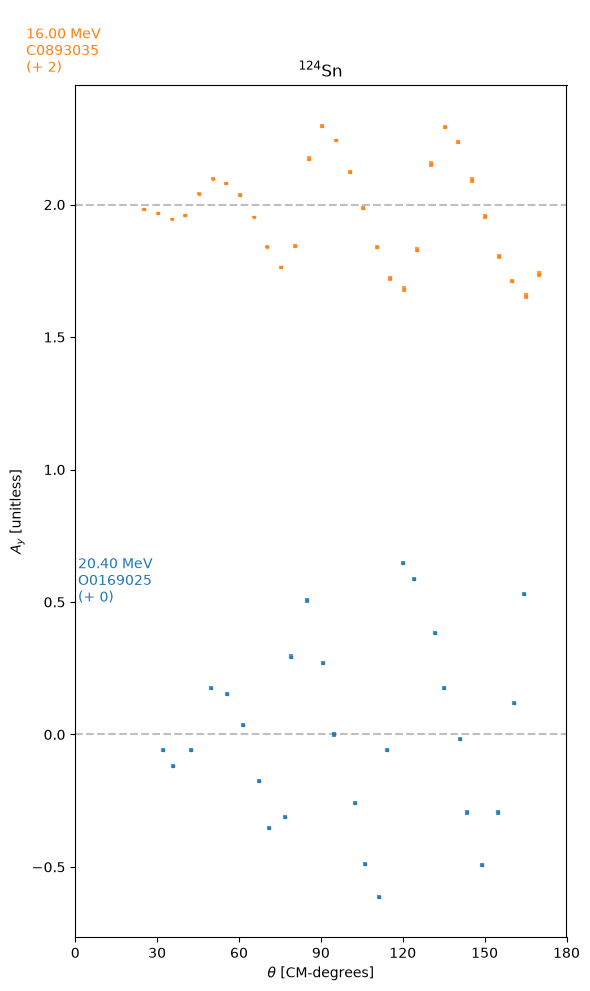

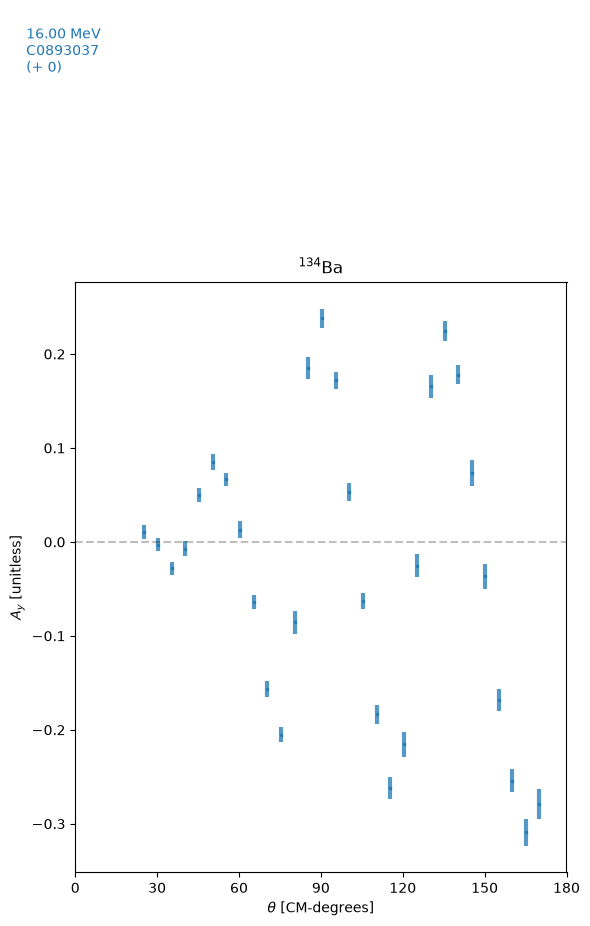

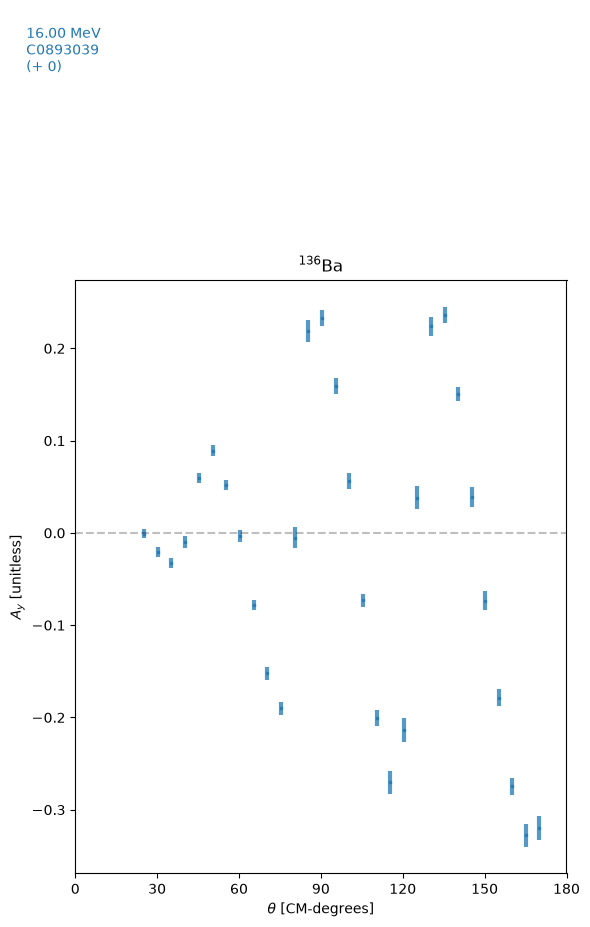

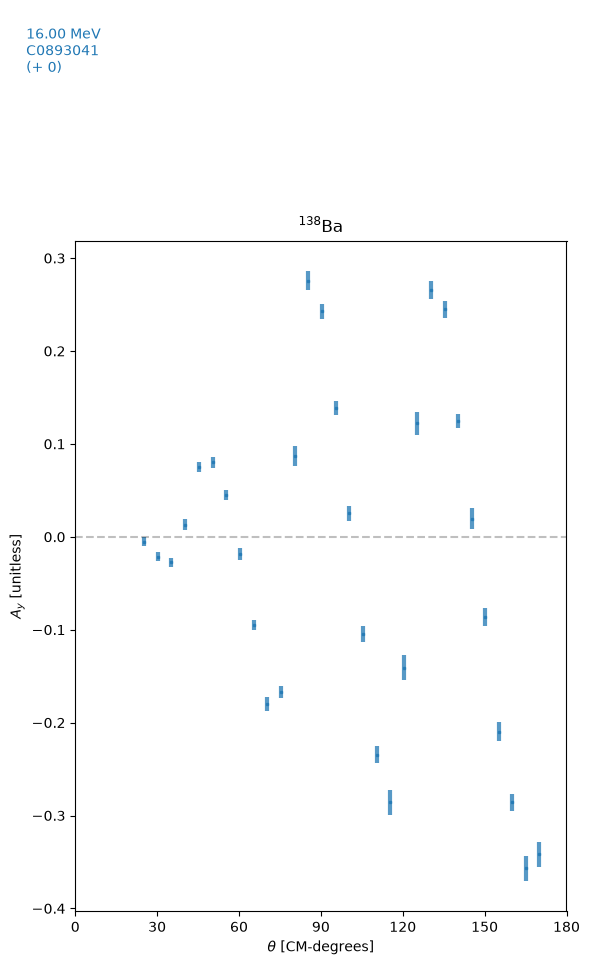

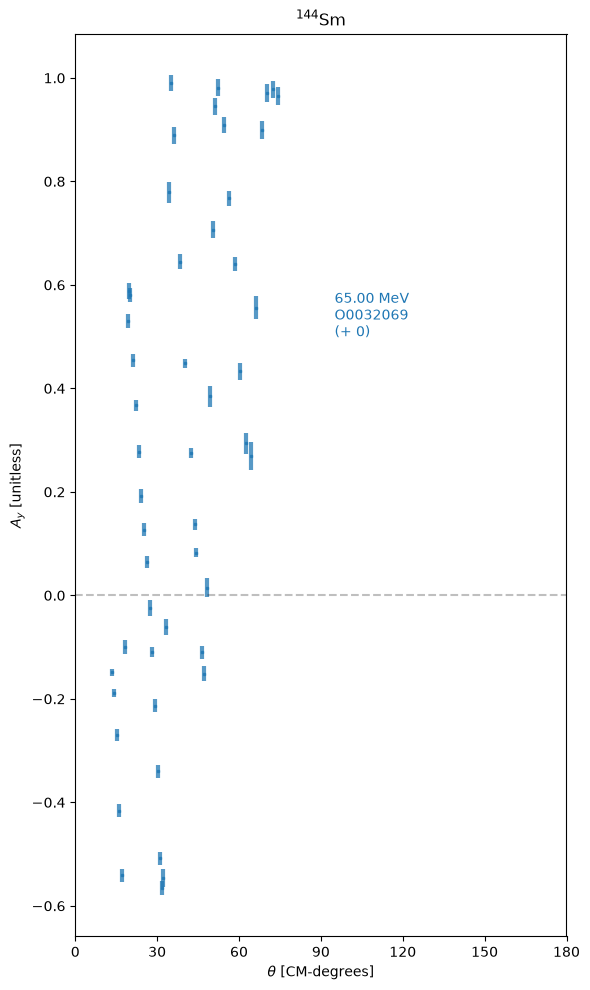

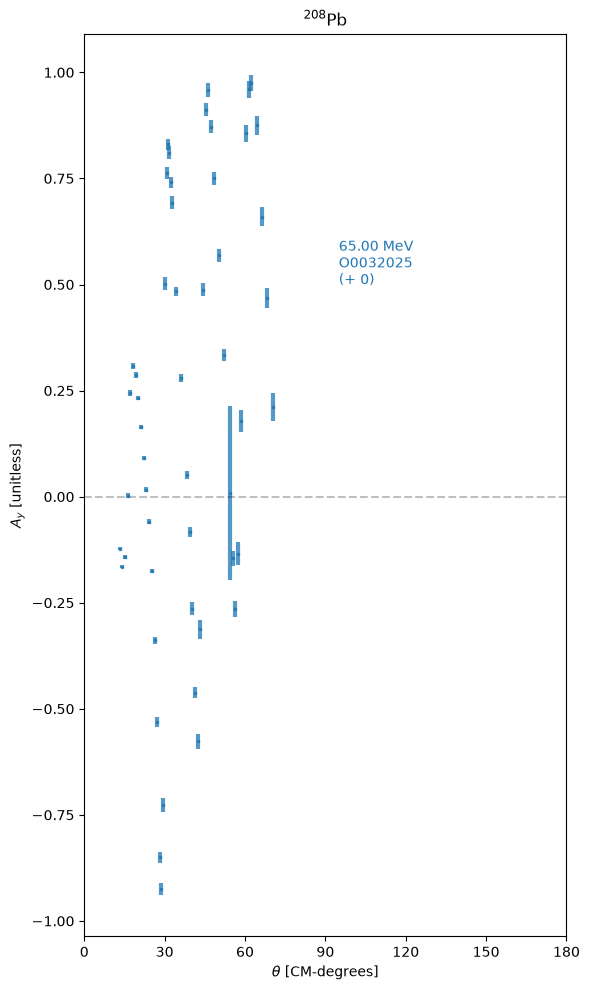

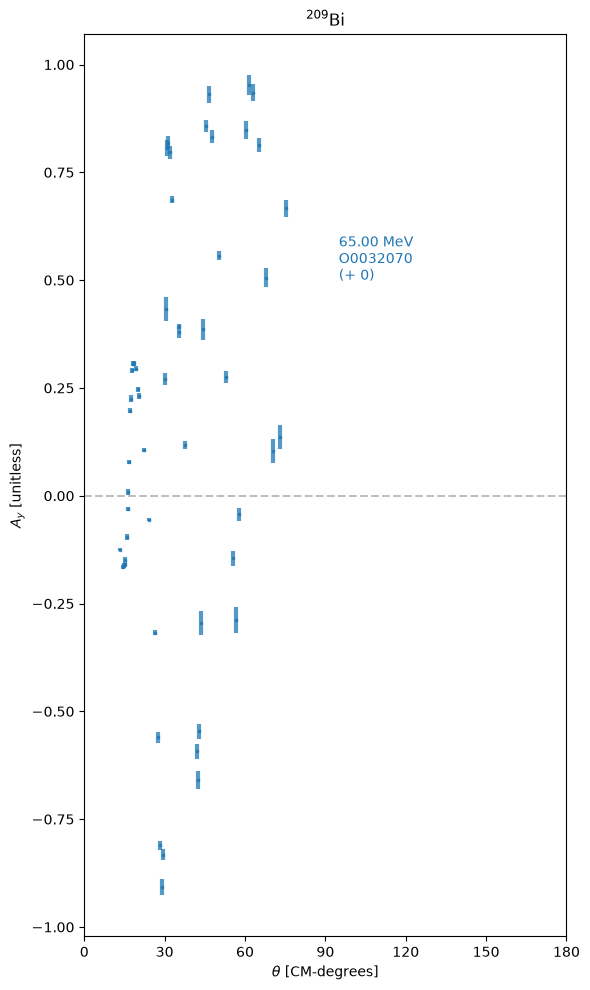

In [6]:
n_plotted = plotting.plot_sector(result)
assert n_plotted == len(result.records), (
    f"{len(result.records) - n_plotted} of {len(result.records)} data sets were not plotted")
print(f"plotted all {n_plotted} data sets")
plt.show()

## Write

`corpus.write` re-checks coverage against the allowlist before writing, so a data set
that silently disappears from EXFOR fails here rather than passing unnoticed.

In [7]:
corpus.write(result)
print(f"wrote {len(result.records)} measurements to data/{result.corpus}/{result.sector}/")

wrote 64 measurements to data/chuq/proton_ay/
